# S&P 500 Monthly Forecasting Study

This notebook evaluates whether forecasting models can beat a simple **naive random-walk baseline** for the monthly S&P 500 index and recommends one model for production.

**Business questions**
1. Can any forecasting model outperform the naive model, where next month equals this month?
2. If one model had to be deployed, which model is the best choice and why?

The workflow follows the Week 8 notebook structure, but uses the already-downloaded local dataset at `dataset/sp500_monthly.csv`.

## Environment Setup

Run the installation cell once if your notebook kernel does not already have the required packages.

In [1]:
%pip install -q pandas numpy matplotlib seaborn scipy statsmodels scikit-learn prophet xgboost lightgbm tensorflow

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller, kpss

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

SEED = 42
np.random.seed(SEED)

DATA_PATH = Path("dataset/sp500_monthly.csv")
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

print("Libraries imported successfully.")

Libraries imported successfully.


In [ ]:
def load_sp500_csv(path: Path) -> pd.Series:
    raw = pd.read_csv(path, skiprows=[1, 2])
    if "Date" not in raw.columns:
        raw = raw.rename(columns={raw.columns[0]: "Date"})

    df = raw[["Date", "Close"]].copy()
    df["Date"] = pd.to_datetime(df["Date"])
    df["Close"] = pd.to_numeric(df["Close"], errors="coerce")
    df = df.dropna(subset=["Date", "Close"]).sort_values("Date")
    df = df.drop_duplicates(subset="Date", keep="last")
    df = df.set_index("Date").resample("MS").last()
    df.index = pd.DatetimeIndex(df.index, freq="MS", name="Date")
    return df["Close"].rename("SP500")


def stationarity_report(series: pd.Series, label: str) -> dict:
    adf_stat, adf_p, *_ = adfuller(series.dropna(), autolag="AIC")
    kpss_stat, kpss_p, *_ = kpss(series.dropna(), regression="c", nlags="auto")
    adf_msg = "Reject unit root -> stationary" if adf_p < 0.05 else "Fail to reject unit root -> non-stationary"
    kpss_msg = "Fail to reject stationarity -> stationary" if kpss_p > 0.05 else "Reject stationarity -> non-stationary"
    return {
        "Series": label,
        "ADF Statistic": adf_stat,
        "ADF p-value": adf_p,
        "ADF Interpretation": adf_msg,
        "KPSS Statistic": kpss_stat,
        "KPSS p-value": kpss_p,
        "KPSS Interpretation": kpss_msg,
    }


def make_features(log_series: pd.Series) -> pd.DataFrame:
    df = pd.DataFrame({"y": log_series})
    for lag in [1, 2, 3, 6, 12]:
        df[f"lag_{lag}"] = df["y"].shift(lag)

    shifted = df["y"].shift(1)
    df["roll_3_mean"] = shifted.rolling(3).mean()
    df["roll_6_std"] = shifted.rolling(6).std()
    df["roll_12_mean"] = shifted.rolling(12).mean()
    df["month"] = df.index.month
    df["quarter"] = df.index.quarter
    df["year"] = df.index.year
    df["trend"] = np.arange(len(df))
    return df.dropna()

def recursive_forecast(model, history_log_values, steps, feature_cols, history_start):
    history = list(history_log_values)
    forecasts = []
    lower = float(np.min(history_log_values) - 0.25)
    upper = float(np.max(history_log_values) + 0.25)
    for _ in range(steps):
        hist_index = pd.date_range(history_start, periods=len(history), freq="MS")
        hist_series = pd.Series(history, index=hist_index)
        row = make_features(hist_series).iloc[-1][feature_cols]
        pred = model.predict(row.to_frame().T)[0]
        pred = float(np.clip(pred, lower, upper))
        forecasts.append(pred)
        history.append(pred)
    return np.array(forecasts)


def compute_metrics(actual, predicted, naive_pred, prev_actual):
    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)
    naive_pred = np.asarray(naive_pred, dtype=float)
    prev_actual = np.asarray(prev_actual, dtype=float)

    err = actual - predicted
    naive_mae = mean_absolute_error(actual, naive_pred)
    direction_actual = np.sign(actual - prev_actual)
    direction_pred = np.sign(predicted - prev_actual)

    return {
        "MAE": mean_absolute_error(actual, predicted),
        "RMSE": np.sqrt(mean_squared_error(actual, predicted)),
        "MAPE": np.mean(np.abs(err / actual)) * 100,
        "MASE": mean_absolute_error(actual, predicted) / naive_mae,
        "R2": r2_score(actual, predicted),
        "Bias": np.mean(err),
        "Directional_Accuracy": np.mean(direction_actual == direction_pred) * 100,
    }


def dm_test(actual, pred_a, pred_b, h=1, power=2):
    e1 = np.asarray(actual) - np.asarray(pred_a)
    e2 = np.asarray(actual) - np.asarray(pred_b)
    d = np.abs(e1) ** power - np.abs(e2) ** power
    T = len(d)
    mean_d = d.mean()

    gamma0 = np.var(d, ddof=1)
    gamma = 0.0
    if h > 1:
        for lag in range(1, h):
            cov = np.cov(d[lag:], d[:-lag], ddof=1)[0, 1]
            gamma += 2 * cov

    var_d = (gamma0 + gamma) / T
    dm_stat = mean_d / np.sqrt(var_d)
    harvey = np.sqrt((T + 1 - 2 * h + (h * (h - 1) / T)) / T)
    dm_stat *= harvey
    p_value = 2 * (1 - stats.t.cdf(np.abs(dm_stat), df=T - 1))
    return {"dm_stat": dm_stat, "p_value": p_value, "loss_diff": d}


def plot_forecast(train, test, forecast, title, lower=None, upper=None):
    fig, ax = plt.subplots(figsize=(12, 5))
    train.iloc[-60:].plot(ax=ax, label="Train (last 5 years)", color="steelblue")
    test.plot(ax=ax, label="Actual", color="black", linewidth=2)
    pd.Series(forecast, index=test.index).plot(ax=ax, label="Forecast", color="tomato", linewidth=2)
    if lower is not None and upper is not None:
        ax.fill_between(test.index, lower, upper, color="tomato", alpha=0.2, label="Interval")
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.show()

---
## Part 1. Data Preparation

In [ ]:
series = load_sp500_csv(DATA_PATH)
df = series.to_frame()

print(df.head())
print()
print(f"Start date: {df.index.min().date()}")
print(f"End date  : {df.index.max().date()}")
print(f"Observations: {len(df)}")
print(f"Index dtype: {df.index.dtype}")
print(f"Index freq : {df.index.freqstr}")

                 SP500
Date                  
1990-01-01  329.079987
1990-02-01  331.890015
1990-03-01  339.940002
1990-04-01  330.799988
1990-05-01  361.230011

Start date: 1990-01-01
End date  : 2026-07-01
Observations: 439
Index dtype: datetime64[us]
Index freq : MS


In [ ]:
monthly_df = df.resample("MS").last()
monthly_df.index = pd.DatetimeIndex(monthly_df.index, freq="MS", name="Date")

print("Monthly data check")
print(monthly_df.head())
print(f"Monthly frequency confirmed: {monthly_df.index.freqstr}")

Monthly data check
                 SP500
Date                  
1990-01-01  329.079987
1990-02-01  331.890015
1990-03-01  339.940002
1990-04-01  330.799988
1990-05-01  361.230011
Monthly frequency confirmed: MS


,original,with_missing,forward_fill,interpolated
Date,,,,
1990-11-01,322.220001,NaN,304.000000,317.324919
1994-03-01,445.769989,NaN,467.140015,459.437637
2000-01-01,1394.459961,NaN,1469.250000,1417.835022
2006-09-01,1335.849976,NaN,1303.819946,1341.487485
2015-11-01,2080.409912,NaN,2079.360107,2061.359695


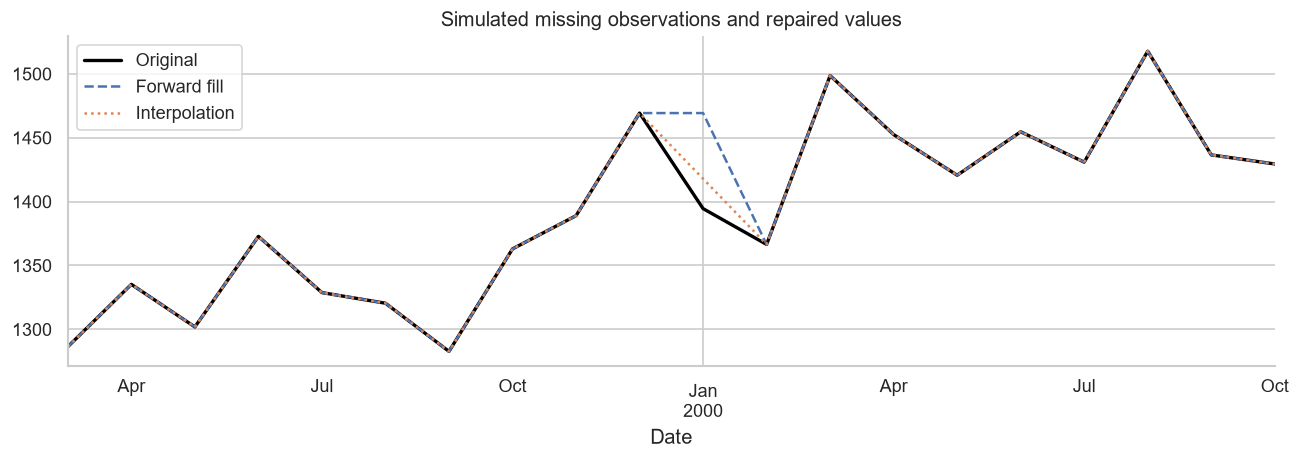

Missing-value handling matters because time-series models require a continuous timeline. Gaps can distort lag features, rolling statistics, and state-space estimation, which can lead to biased forecasts or model failures.


In [ ]:
s_gap = series.copy()
missing_locs = [10, 50, 120, 200, 310]
s_gap.iloc[missing_locs] = np.nan

s_ffill = s_gap.ffill()
s_interp = s_gap.interpolate(method="time")

compare = pd.DataFrame(
    {
        "original": series.iloc[missing_locs],
        "with_missing": s_gap.iloc[missing_locs],
        "forward_fill": s_ffill.iloc[missing_locs],
        "interpolated": s_interp.iloc[missing_locs],
    }
)
display(compare)

window = slice(110, 130)
fig, ax = plt.subplots(figsize=(11, 4))
series.iloc[window].plot(ax=ax, label="Original", color="black", linewidth=2)
s_ffill.iloc[window].plot(ax=ax, label="Forward fill", linestyle="--")
s_interp.iloc[window].plot(ax=ax, label="Interpolation", linestyle=":")
ax.set_title("Simulated missing observations and repaired values")
ax.legend()
plt.tight_layout()
plt.show()

print(
    "Missing-value handling matters because time-series models require a continuous timeline. "
    "Gaps can distort lag features, rolling statistics, and state-space estimation, which can "
    "lead to biased forecasts or model failures."
)

In [ ]:
log_series = np.log(series)
log_returns = log_series.diff().dropna()

stationarity_df = pd.DataFrame(
    [
        stationarity_report(series, "Price level"),
        stationarity_report(log_series, "Log price"),
        stationarity_report(log_returns, "Log return"),
    ]
)
display(stationarity_df)

,Series,ADF Statistic,ADF p-value,ADF Interpretation,KPSS Statistic,KPSS p-value,KPSS Interpretation
0,Price level,3.814351,1.000000,Fail to reject unit root -> non-stationary,2.622271,0.01,Reject stationarity -> non-stationary
1,Log price,-0.102753,0.949164,Fail to reject unit root -> non-stationary,3.057313,0.01,Reject stationarity -> non-stationary
2,Log return,-20.836819,0.000000,Reject unit root -> stationary,0.130291,0.10,Fail to reject stationarity -> stationary


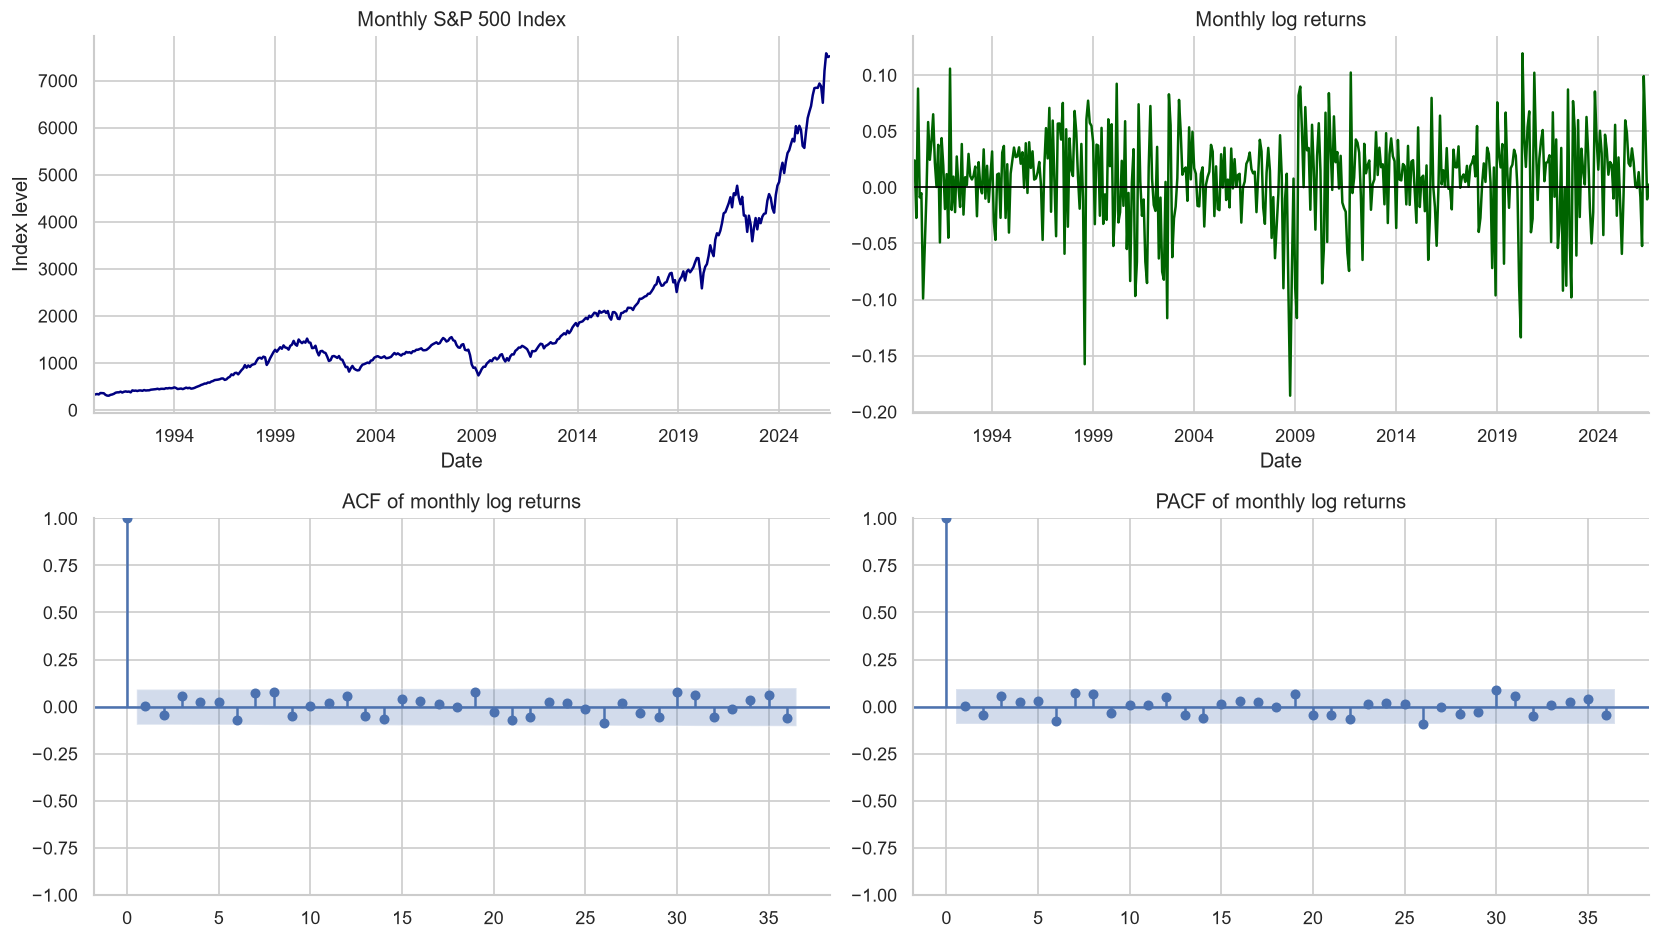

Observation summary: price levels trend upward and are clearly non-stationary, while monthly log returns fluctuate around zero with much weaker serial dependence. ACF and PACF spikes should help guide the SARIMA specification, but equity-index returns are usually close to white noise.


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

series.plot(ax=axes[0, 0], color="navy", title="Monthly S&P 500 Index")
axes[0, 0].set_ylabel("Index level")

log_returns.plot(ax=axes[0, 1], color="darkgreen", title="Monthly log returns")
axes[0, 1].axhline(0, color="black", linewidth=1)

plot_acf(log_returns, lags=36, ax=axes[1, 0], title="ACF of monthly log returns")
plot_pacf(log_returns, lags=36, ax=axes[1, 1], title="PACF of monthly log returns", method="ywm")

plt.tight_layout()
plt.show()

print(
    "Observation summary: price levels trend upward and are clearly non-stationary, while monthly "
    "log returns fluctuate around zero with much weaker serial dependence. ACF and PACF spikes "
    "should help guide the SARIMA specification, but equity-index returns are usually close to white noise."
)

---
## Part 2. Classical Forecasting Models

In [ ]:
TRAIN_MONTHS = 360
train = series.iloc[:TRAIN_MONTHS].copy()
test = series.iloc[TRAIN_MONTHS:].copy()
log_train = np.log(train)
H = len(test)

TRAIN_END = train.index[-1]
TEST_START = test.index[0]
prev_actual = np.r_[train.iloc[-1], test.iloc[:-1].values]

print(f"Train window: {train.index[0].date()} to {train.index[-1].date()} ({len(train)} months)")
print(f"Test window : {test.index[0].date()} to {test.index[-1].date()} ({len(test)} months)")
print(f"Forecast horizon H = {H} months")

Train window: 1990-01-01 to 2019-12-01 (360 months)
Test window : 2020-01-01 to 2026-07-01 (79 months)
Forecast horizon H = 79 months


In [ ]:
results = {}
intervals = {}
metrics_records = {}

naive_fc = prev_actual.copy()
results["Naive"] = naive_fc
metrics_records["Naive"] = compute_metrics(test.values, naive_fc, naive_fc, prev_actual)

print("Naive baseline metrics")
print(pd.Series(metrics_records["Naive"]).round(4))

Naive baseline metrics
MAE                     180.5700
RMSE                    218.4257
MAPE                      4.0223
MASE                      1.0000
R2                        0.9690
Bias                     54.2667
Directional_Accuracy      0.0000
dtype: float64


Holt-Winters smoothing parameters
{'smoothing_level': np.float64(0.9999999850988388), 'smoothing_trend': np.float64(0.0), 'smoothing_seasonal': np.float64(1.0575559309311794e-08), 'damping_trend': nan, 'initial_level': np.float64(5.789013086417855), 'initial_trend': np.float64(0.00635881174597087), 'initial_seasons': array([ 0.00093123, -0.0028715 ,  0.00313173,  0.01216552,  0.01342228,
        0.00455419,  0.00726351, -0.00871947, -0.01902239, -0.01299611,
       -0.00420394,  0.00223562]), 'use_boxcox': False, 'lamda': None, 'remove_bias': False}

MAE                     715.7487
RMSE                    940.1102
MAPE                     13.1082
MASE                      3.9638
R2                        0.4254
Bias                    630.0108
Directional_Accuracy     49.3671
dtype: float64


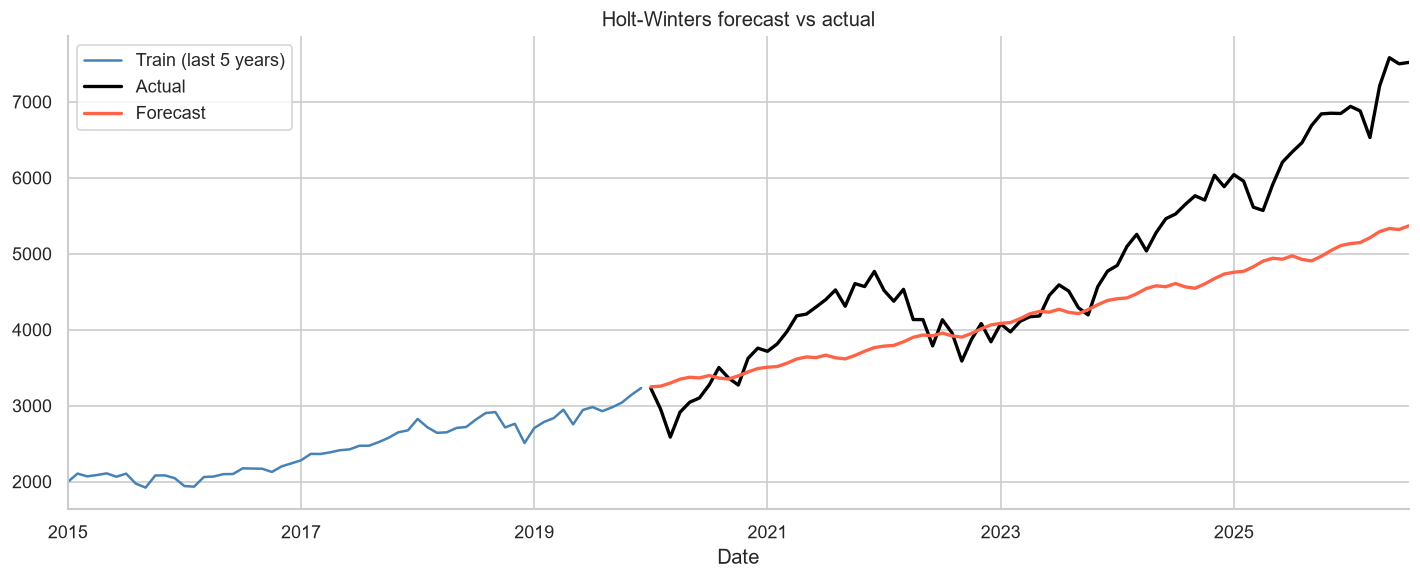

In [ ]:
hw_model = ExponentialSmoothing(
    log_train,
    trend="add",
    seasonal="add",
    seasonal_periods=12,
    initialization_method="estimated",
).fit(optimized=True)

hw_log_fc = hw_model.forecast(H)
hw_fc = np.exp(hw_log_fc.values)

results["Holt-Winters"] = hw_fc
metrics_records["Holt-Winters"] = compute_metrics(test.values, hw_fc, naive_fc, prev_actual)

print("Holt-Winters smoothing parameters")
print(hw_model.params)
print()
print(pd.Series(metrics_records["Holt-Winters"]).round(4))

plot_forecast(train, test, hw_fc, "Holt-Winters forecast vs actual")

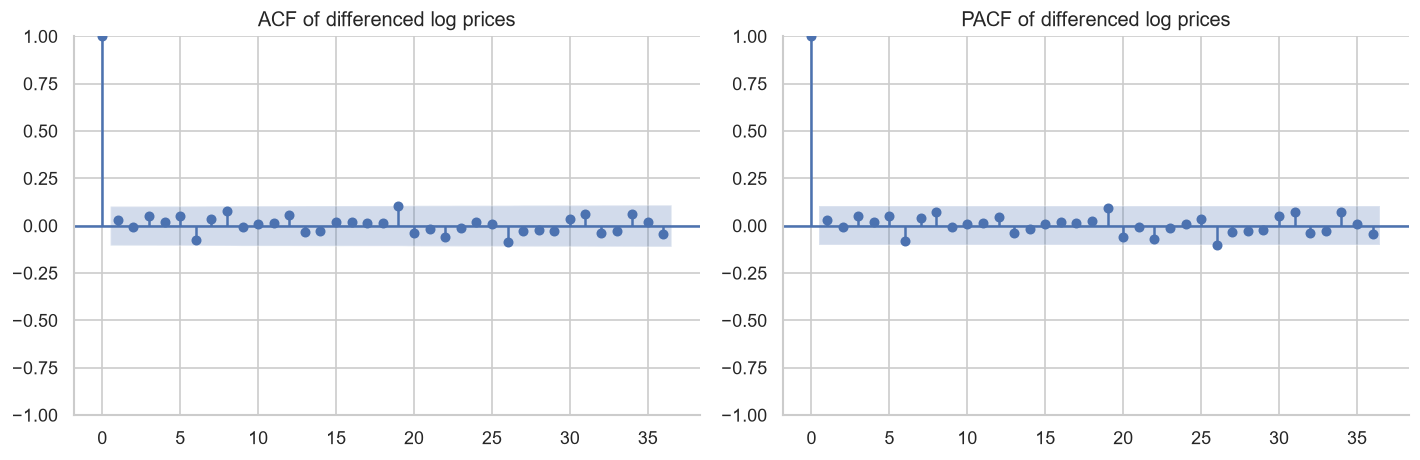

,order,seasonal_order,aic,bic,lb_pvalue_12
8,"(0, 1, 2)","(0, 0, 0, 12)",-1246.170182,-1234.545389,1.0
9,"(0, 1, 2)","(0, 0, 1, 12)",-1209.220611,-1193.858044,1.0
5,"(0, 1, 1)","(0, 0, 1, 12)",-1215.707845,-1204.177212,1.0
4,"(0, 1, 1)","(0, 0, 0, 12)",-1252.196682,-1244.441211,1.0
1,"(0, 1, 0)","(0, 0, 1, 12)",-1221.465267,-1213.772389,1.0
0,"(0, 1, 0)","(0, 0, 0, 12)",-1257.444714,-1253.564181,1.0
25,"(2, 1, 0)","(0, 0, 1, 12)",-1218.103746,-1202.717991,1.0
13,"(1, 1, 0)","(0, 0, 1, 12)",-1220.081151,-1208.541835,1.0
24,"(2, 1, 0)","(0, 0, 0, 12)",-1250.301221,-1238.668013,1.0
12,"(1, 1, 0)","(0, 0, 0, 12)",-1256.422017,-1248.660951,1.0


Selected SARIMA order: (0, 1, 0), seasonal order: (0, 0, 0, 12)


In [ ]:
diff_log = log_train.diff().dropna()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(diff_log, lags=36, ax=axes[0], title="ACF of differenced log prices")
plot_pacf(diff_log, lags=36, ax=axes[1], title="PACF of differenced log prices", method="ywm")
plt.tight_layout()
plt.show()

candidate_rows = []
best_aic = np.inf
best_order = None
best_model = None

for p in range(0, 3):
    for q in range(0, 3):
        for P in range(0, 2):
            for Q in range(0, 2):
                try:
                    model = SARIMAX(
                        log_train,
                        order=(p, 1, q),
                        seasonal_order=(P, 0, Q, 12),
                        enforce_stationarity=False,
                        enforce_invertibility=False,
                    ).fit(disp=False)

                    resid = model.resid.dropna()
                    lb_p = acorr_ljungbox(resid, lags=[12], return_df=True)["lb_pvalue"].iloc[0]
                    candidate_rows.append(
                        {
                            "order": (p, 1, q),
                            "seasonal_order": (P, 0, Q, 12),
                            "aic": model.aic,
                            "bic": model.bic,
                            "lb_pvalue_12": lb_p,
                        }
                    )

                    if lb_p > 0.05 and model.aic < best_aic:
                        best_aic = model.aic
                        best_order = ((p, 1, q), (P, 0, Q, 12))
                        best_model = model
                except Exception:
                    continue

candidate_df = pd.DataFrame(candidate_rows).sort_values(["lb_pvalue_12", "aic"], ascending=[False, True])
display(candidate_df.head(10))

if best_model is None:
    best_order = ((0, 1, 0), (0, 0, 0, 12))
    best_model = SARIMAX(
        log_train,
        order=best_order[0],
        seasonal_order=best_order[1],
        enforce_stationarity=False,
        enforce_invertibility=False,
    ).fit(disp=False)

print(f"Selected SARIMA order: {best_order[0]}, seasonal order: {best_order[1]}")

,lb_stat,lb_pvalue
6,0.0914,1.0
12,0.2830,1.0
24,0.5447,1.0


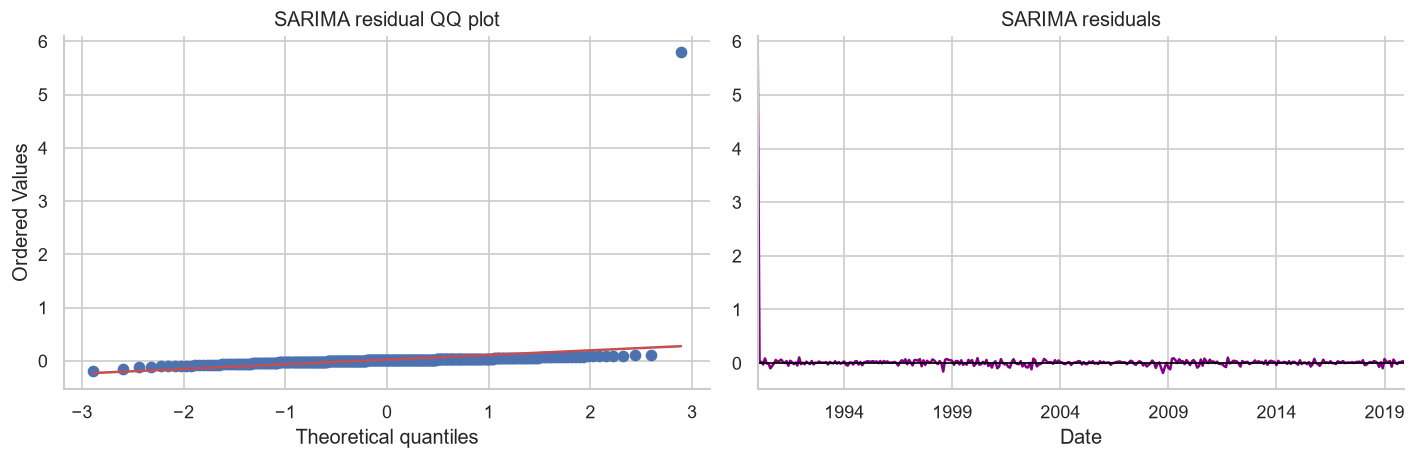

Ljung-Box p-values above 0.05 indicate residuals are close to white noise. If some lags fail, the model may still be usable, but it suggests remaining structure.


In [ ]:
sarima = best_model
sarima_resid = sarima.resid.dropna()
lb = acorr_ljungbox(sarima_resid, lags=[6, 12, 24], return_df=True)
display(lb[["lb_stat", "lb_pvalue"]].round(4))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
stats.probplot(sarima_resid, plot=axes[0])
axes[0].set_title("SARIMA residual QQ plot")
sarima_resid.plot(ax=axes[1], color="purple", title="SARIMA residuals")
axes[1].axhline(0, color="black", linewidth=1)
plt.tight_layout()
plt.show()

print(
    "Ljung-Box p-values above 0.05 indicate residuals are close to white noise. "
    "If some lags fail, the model may still be usable, but it suggests remaining structure."
)

MAE                     1640.9881
RMSE                    2025.5289
MAPE                      30.1069
MASE                       9.0878
R2                        -1.6672
Bias                    1601.4103
Directional_Accuracy      37.9747
dtype: float64


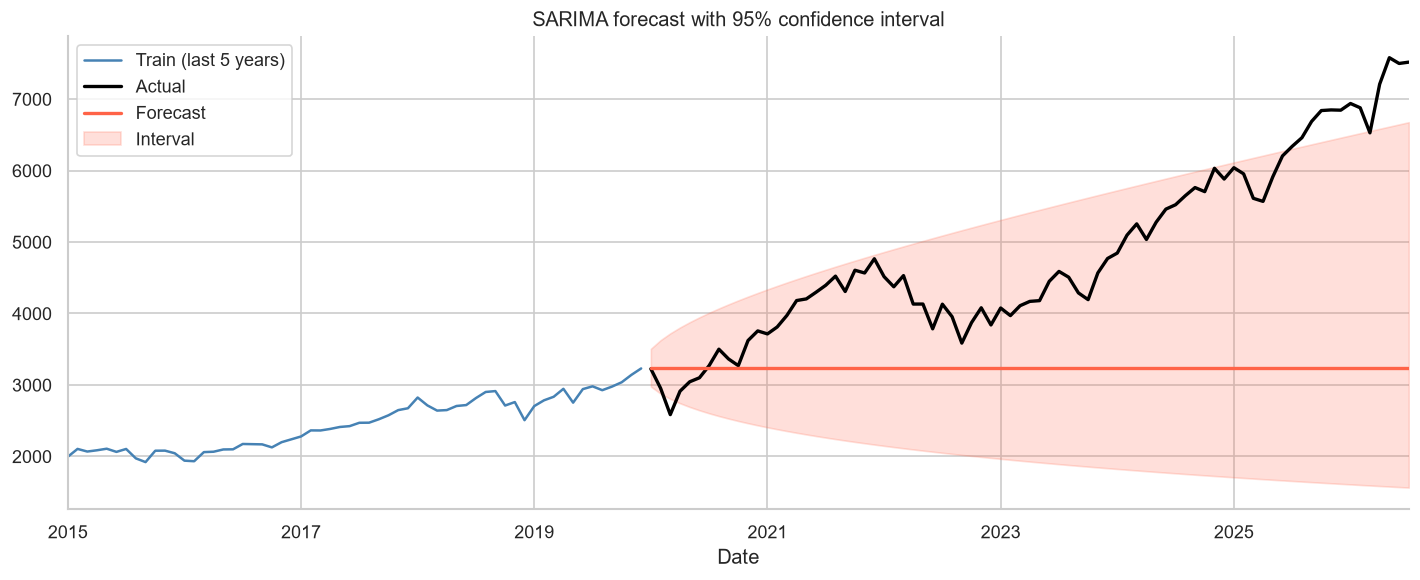

In [ ]:
sarima_fc_obj = sarima.get_forecast(steps=H)
sarima_log_mean = sarima_fc_obj.predicted_mean
sarima_log_ci = sarima_fc_obj.conf_int(alpha=0.05)

sarima_fc = np.exp(sarima_log_mean.values)
sarima_lo = np.exp(sarima_log_ci.iloc[:, 0].values)
sarima_hi = np.exp(sarima_log_ci.iloc[:, 1].values)

results["SARIMA"] = sarima_fc
intervals["SARIMA"] = (sarima_lo, sarima_hi)
metrics_records["SARIMA"] = compute_metrics(test.values, sarima_fc, naive_fc, prev_actual)

print(pd.Series(metrics_records["SARIMA"]).round(4))
plot_forecast(train, test, sarima_fc, "SARIMA forecast with 95% confidence interval", sarima_lo, sarima_hi)

---
## Part 3. Automated Model: Prophet

Importing plotly failed. Interactive plots will not work.


22:51:35 - cmdstanpy - INFO - Chain [1] start processing


22:51:35 - cmdstanpy - INFO - Chain [1] done processing


MAE                     731.9985
RMSE                    935.0538
MAPE                     13.4979
MASE                      4.0538
R2                        0.4316
Bias                    691.5622
Directional_Accuracy     51.8987
dtype: float64


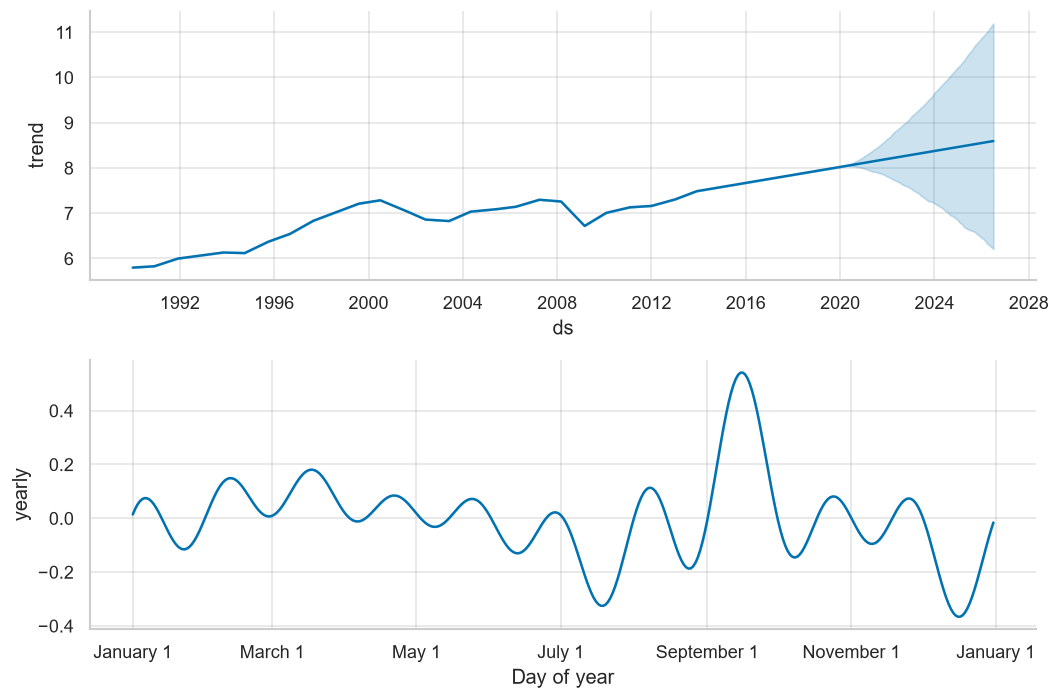

In [ ]:
from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics

prophet_df = log_train.rename_axis("ds").reset_index(name="y")

prophet_model = Prophet(
    changepoint_prior_scale=0.5,
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode="additive",
)
prophet_model.fit(prophet_df)

future = prophet_model.make_future_dataframe(periods=H, freq="MS")
prophet_fc = prophet_model.predict(future)
prophet_test = np.exp(prophet_fc.tail(H)["yhat"].values)

results["Prophet"] = prophet_test
metrics_records["Prophet"] = compute_metrics(test.values, prophet_test, naive_fc, prev_actual)

print(pd.Series(metrics_records["Prophet"]).round(4))

fig = prophet_model.plot_components(prophet_fc)
plt.tight_layout()
plt.show()

In [ ]:
prophet_cv = cross_validation(
    prophet_model,
    initial="3650 days",
    period="180 days",
    horizon="365 days",
    parallel=None,
)
prophet_pm = performance_metrics(prophet_cv)

display(prophet_pm[["horizon", "rmse", "mape", "coverage"]].head())
print(f"Mean Prophet CV RMSE in log space: {prophet_pm['rmse'].mean():.5f}")
print(
    "Interpretation: Prophet decomposes the series into trend plus seasonality. "
    "For a broad equity index, the trend component is usually more informative than seasonality."
)


  0%|          | 0/39 [00:00<?, ?it/s]

22:51:36 - cmdstanpy - INFO - Chain [1] start processing


22:51:36 - cmdstanpy - INFO - Chain [1] done processing



  3%|▎         | 1/39 [00:00<00:08,  4.47it/s]

22:51:36 - cmdstanpy - INFO - Chain [1] start processing


...

22:51:44 - cmdstanpy - INFO - Chain [1] done processing



100%|██████████| 39/39 [00:08<00:00,  3.64it/s]


100%|██████████| 39/39 [00:08<00:00,  4.51it/s]

,horizon,rmse,mape,coverage
0,37 days,0.140495,0.013854,0.423913
1,38 days,0.156872,0.015276,0.413043
2,40 days,0.160591,0.015699,0.413043
3,41 days,0.159968,0.015571,0.423913
4,42 days,0.159247,0.015501,0.420290


Mean Prophet CV RMSE in log space: 0.19839
Interpretation: Prophet decomposes the series into trend plus seasonality. For a broad equity index, the trend component is usually more informative than seasonality.


---
## Part 4. Machine Learning Models

In [ ]:
full_features = make_features(log_series)
FEATURE_COLS = [c for c in full_features.columns if c != "y"]

train_features = full_features.loc[:TRAIN_END]
test_features = full_features.loc[TEST_START:]

X_train = train_features[FEATURE_COLS]
y_train = train_features["y"]
X_test = test_features[FEATURE_COLS]
y_test = test_features["y"]

print(f"Engineered features ({len(FEATURE_COLS)}): {FEATURE_COLS}")
print(f"Training rows after feature engineering: {len(X_train)}")
print(f"Testing rows after feature engineering : {len(X_test)}")

Engineered features (12): ['lag_1', 'lag_2', 'lag_3', 'lag_6', 'lag_12', 'roll_3_mean', 'roll_6_std', 'roll_12_mean', 'month', 'quarter', 'year', 'trend']
Training rows after feature engineering: 348
Testing rows after feature engineering : 79


In [ ]:
tscv = TimeSeriesSplit(n_splits=4, test_size=12)

lr_fold_scores = []
xgb_fold_scores = []

from xgboost import XGBRegressor

for fold, (tr_idx, val_idx) in enumerate(tscv.split(X_train), start=1):
    Xtr, Xval = X_train.iloc[tr_idx], X_train.iloc[val_idx]
    ytr, yval = y_train.iloc[tr_idx], y_train.iloc[val_idx]

    lr = LinearRegression()
    lr.fit(Xtr, ytr)
    lr_pred = lr.predict(Xval)
    lr_rmse = np.sqrt(mean_squared_error(yval, lr_pred))
    lr_fold_scores.append(lr_rmse)

    xgb = XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.9,
        colsample_bytree=0.9,
        objective="reg:squarederror",
        random_state=SEED,
    )
    xgb.fit(Xtr, ytr)
    xgb_pred = xgb.predict(Xval)
    xgb_rmse = np.sqrt(mean_squared_error(yval, xgb_pred))
    xgb_fold_scores.append(xgb_rmse)

    print(f"Fold {fold}: {Xval.index[0].date()} to {Xval.index[-1].date()}")
    print(f"  Linear Regression RMSE: {lr_rmse:.5f}")
    print(f"  XGBoost RMSE          : {xgb_rmse:.5f}")

print()
print(f"Average Linear Regression CV RMSE: {np.mean(lr_fold_scores):.5f}")
print(f"Average XGBoost CV RMSE          : {np.mean(xgb_fold_scores):.5f}")

Fold 1: 2016-01-01 to 2016-12-01
  Linear Regression RMSE: 0.02876
  XGBoost RMSE          : 0.06104
Fold 2: 2017-01-01 to 2017-12-01
  Linear Regression RMSE: 0.01618
  XGBoost RMSE          : 0.16926


Fold 3: 2018-01-01 to 2018-12-01
  Linear Regression RMSE: 0.04614
  XGBoost RMSE          : 0.06347
Fold 4: 2019-01-01 to 2019-12-01
  Linear Regression RMSE: 0.04223
  XGBoost RMSE          : 0.11021

Average Linear Regression CV RMSE: 0.03333
Average XGBoost CV RMSE          : 0.10100


In [ ]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_log_fc = recursive_forecast(lr_model, log_train.values, H, FEATURE_COLS, log_train.index[0])
lr_fc = np.exp(lr_log_fc)

results["Linear Regression"] = lr_fc
metrics_records["Linear Regression"] = compute_metrics(test.values, lr_fc, naive_fc, prev_actual)

from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.9,
    colsample_bytree=0.9,
    objective="reg:squarederror",
    random_state=SEED,
)
xgb_model.fit(X_train, y_train)
xgb_log_fc = recursive_forecast(xgb_model, log_train.values, H, FEATURE_COLS, log_train.index[0])
xgb_fc = np.exp(xgb_log_fc)

results["XGBoost"] = xgb_fc
metrics_records["XGBoost"] = compute_metrics(test.values, xgb_fc, naive_fc, prev_actual)

display(
    pd.DataFrame(
        {
            "Linear Regression": metrics_records["Linear Regression"],
            "XGBoost": metrics_records["XGBoost"],
        }
    ).round(4)
)

,Linear Regression,XGBoost
MAE,1695.5208,1773.2754
RMSE,2301.9426,2148.0532
MAPE,30.5848,32.7837
MASE,9.3898,9.8204
R2,-2.4448,-1.9996
Bias,1658.0383,1750.7110
Directional_Accuracy,41.7722,40.5063


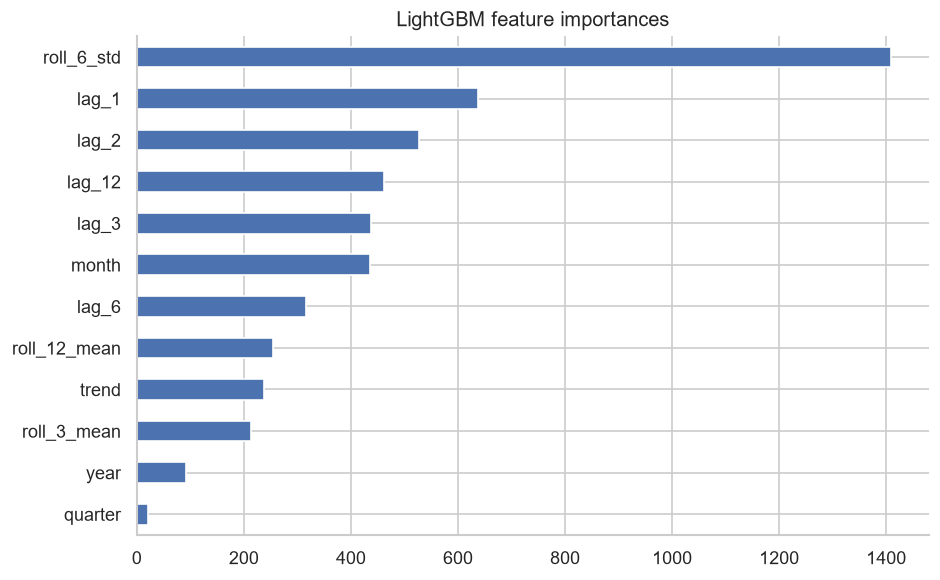

MAE                     1972.5900
RMSE                    2325.1157
MAPE                      36.9919
MASE                      10.9242
R2                        -2.5145
Bias                    1966.3911
Directional_Accuracy      37.9747
dtype: float64


In [ ]:
from lightgbm import LGBMRegressor

lgb_model = LGBMRegressor(
    n_estimators=400,
    learning_rate=0.05,
    num_leaves=31,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=SEED,
    verbose=-1,
)
lgb_model.fit(X_train, y_train)

lgb_log_fc = recursive_forecast(lgb_model, log_train.values, H, FEATURE_COLS, log_train.index[0])
lgb_fc = np.exp(lgb_log_fc)

results["LightGBM"] = lgb_fc
metrics_records["LightGBM"] = compute_metrics(test.values, lgb_fc, naive_fc, prev_actual)

fi = pd.Series(lgb_model.feature_importances_, index=FEATURE_COLS).sort_values()
fi.plot(kind="barh", figsize=(8, 5), title="LightGBM feature importances")
plt.tight_layout()
plt.show()

print(pd.Series(metrics_records["LightGBM"]).round(4))

Empirical LightGBM 95% interval coverage: 6.33%


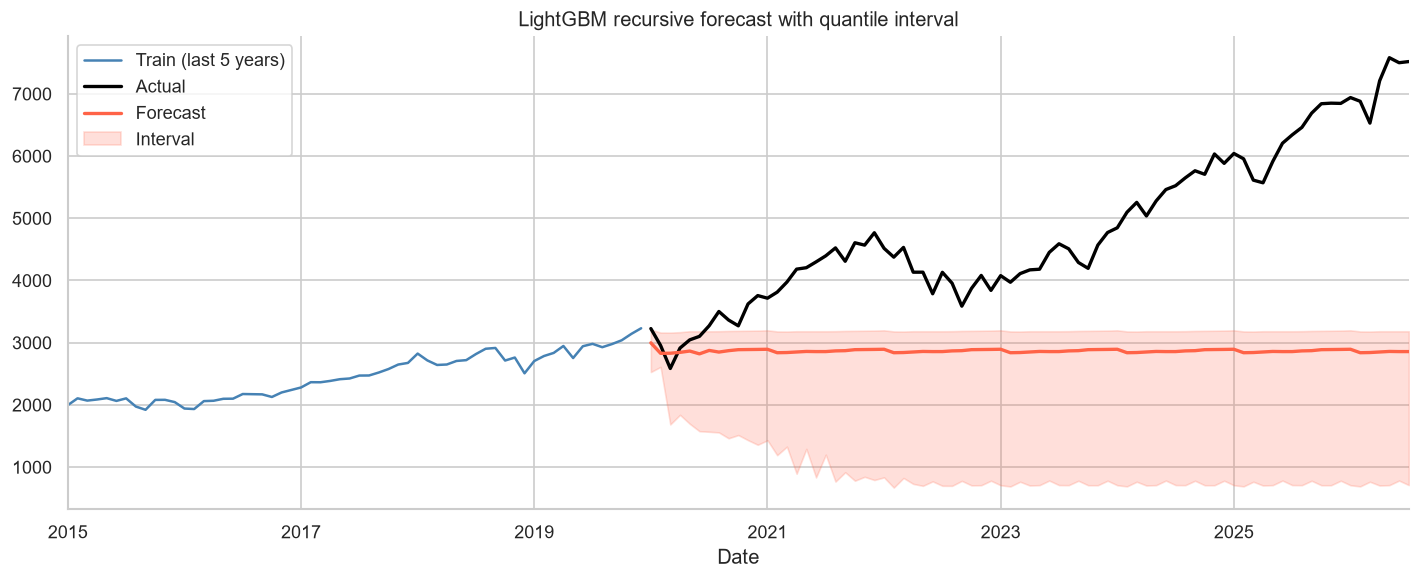

In [ ]:
alpha_lo, alpha_hi = 0.025, 0.975

lgb_lo = LGBMRegressor(
    objective="quantile",
    alpha=alpha_lo,
    n_estimators=400,
    learning_rate=0.05,
    num_leaves=31,
    random_state=SEED,
    verbose=-1,
)
lgb_hi = LGBMRegressor(
    objective="quantile",
    alpha=alpha_hi,
    n_estimators=400,
    learning_rate=0.05,
    num_leaves=31,
    random_state=SEED,
    verbose=-1,
)

lgb_lo.fit(X_train, y_train)
lgb_hi.fit(X_train, y_train)

lo_log = recursive_forecast(lgb_lo, log_train.values, H, FEATURE_COLS, log_train.index[0])
hi_log = recursive_forecast(lgb_hi, log_train.values, H, FEATURE_COLS, log_train.index[0])
lo_fc = np.exp(lo_log)
hi_fc = np.exp(hi_log)

intervals["LightGBM"] = (lo_fc, hi_fc)
coverage = np.mean((test.values >= lo_fc) & (test.values <= hi_fc)) * 100
print(f"Empirical LightGBM 95% interval coverage: {coverage:.2f}%")

plot_forecast(train, test, lgb_fc, "LightGBM recursive forecast with quantile interval", lo_fc, hi_fc)

---
## Part 5. Deep Learning

In [ ]:
mlp_model = Pipeline(
    [
        ("scaler", StandardScaler()),
        (
            "mlp",
            MLPRegressor(
                hidden_layer_sizes=(128, 64, 32),
                activation="relu",
                alpha=1e-4,
                learning_rate_init=0.001,
                max_iter=1000,
                early_stopping=True,
                random_state=SEED,
            ),
        ),
    ]
)
mlp_model.fit(X_train, y_train)
mlp_log_fc = recursive_forecast(mlp_model, log_train.values, H, FEATURE_COLS, log_train.index[0])
mlp_fc = np.exp(mlp_log_fc)

results["MLP"] = mlp_fc
metrics_records["MLP"] = compute_metrics(test.values, mlp_fc, naive_fc, prev_actual)

print(pd.Series(metrics_records["MLP"]).round(4))

MAE                     1036.4508
RMSE                    1412.8851
MAPE                      19.4167
MASE                       5.7399
R2                        -0.2977
Bias                     691.5568
Directional_Accuracy      44.3038
dtype: float64


In [ ]:
import tensorflow as tf

tf.random.set_seed(SEED)

LOOKBACK = 12
scaler = MinMaxScaler()
log_train_scaled = scaler.fit_transform(log_train.values.reshape(-1, 1)).flatten()

X_seq, y_seq = [], []
for i in range(LOOKBACK, len(log_train_scaled)):
    X_seq.append(log_train_scaled[i - LOOKBACK:i])
    y_seq.append(log_train_scaled[i])

X_seq = np.array(X_seq).reshape(-1, LOOKBACK, 1)
y_seq = np.array(y_seq)

lstm_model = tf.keras.Sequential(
    [
        tf.keras.layers.Input(shape=(LOOKBACK, 1)),
        tf.keras.layers.LSTM(64, return_sequences=True),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.LSTM(32),
        tf.keras.layers.Dense(16, activation="relu"),
        tf.keras.layers.Dense(1),
    ]
)
lstm_model.compile(optimizer="adam", loss="mse")
lstm_model.fit(
    X_seq,
    y_seq,
    epochs=50,
    batch_size=16,
    validation_split=0.1,
    verbose=0,
    callbacks=[tf.keras.callbacks.EarlyStopping(patience=8, restore_best_weights=True)],
)

window = list(log_train_scaled[-LOOKBACK:])
lstm_scaled_fc = []
for _ in range(H):
    x_in = np.array(window[-LOOKBACK:]).reshape(1, LOOKBACK, 1)
    pred = float(lstm_model.predict(x_in, verbose=0)[0, 0])
    pred = float(np.clip(pred, log_train_scaled.min() - 0.05, log_train_scaled.max() + 0.05))
    lstm_scaled_fc.append(pred)
    window.append(pred)

lstm_log_fc = scaler.inverse_transform(np.array(lstm_scaled_fc).reshape(-1, 1)).flatten()
lstm_fc = np.exp(lstm_log_fc)

results["LSTM"] = lstm_fc
metrics_records["LSTM"] = compute_metrics(test.values, lstm_fc, naive_fc, prev_actual)

print(pd.Series(metrics_records["LSTM"]).round(4))

MAE                     2252.4530
RMSE                    2626.0225
MAPE                      42.4724
MASE                      12.4741
R2                        -3.4830
Bias                    2244.5149
Directional_Accuracy      37.9747
dtype: float64


---
## Part 6. Evaluation, Diebold-Mariano Test, and Ensemble

,MAE,RMSE,MAPE,MASE,R2,Bias,Directional_Accuracy
Naive,180.5700,218.4257,4.0223,1.0000,0.9690,54.2667,0.0000
Holt-Winters,715.7487,940.1102,13.1082,3.9638,0.4254,630.0108,49.3671
Prophet,731.9985,935.0538,13.4979,4.0538,0.4316,691.5622,51.8987
MLP,1036.4508,1412.8851,19.4167,5.7399,-0.2977,691.5568,44.3038
SARIMA,1640.9881,2025.5289,30.1069,9.0878,-1.6672,1601.4103,37.9747
Linear Regression,1695.5208,2301.9426,30.5848,9.3898,-2.4448,1658.0383,41.7722
XGBoost,1773.2754,2148.0532,32.7837,9.8204,-1.9996,1750.7110,40.5063
LightGBM,1972.5900,2325.1157,36.9919,10.9242,-2.5145,1966.3911,37.9747
LSTM,2252.4530,2626.0225,42.4724,12.4741,-3.4830,2244.5149,37.9747


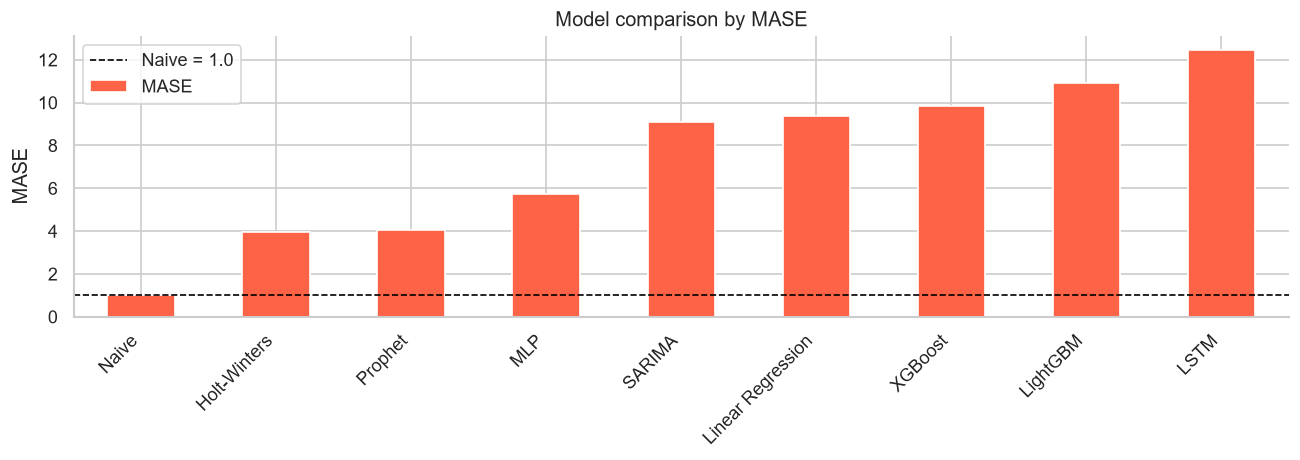

In [ ]:
metrics_df = pd.DataFrame(metrics_records).T
metrics_df = metrics_df[["MAE", "RMSE", "MAPE", "MASE", "R2", "Bias", "Directional_Accuracy"]]
metrics_df = metrics_df.sort_values("MASE")
display(metrics_df.round(4))

fig, ax = plt.subplots(figsize=(11, 4))
colors = ["steelblue" if x < 1 else "tomato" for x in metrics_df["MASE"]]
metrics_df["MASE"].plot(kind="bar", color=colors, ax=ax)
ax.axhline(1.0, color="black", linestyle="--", linewidth=1, label="Naive = 1.0")
ax.set_title("Model comparison by MASE")
ax.set_ylabel("MASE")
ax.legend()
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

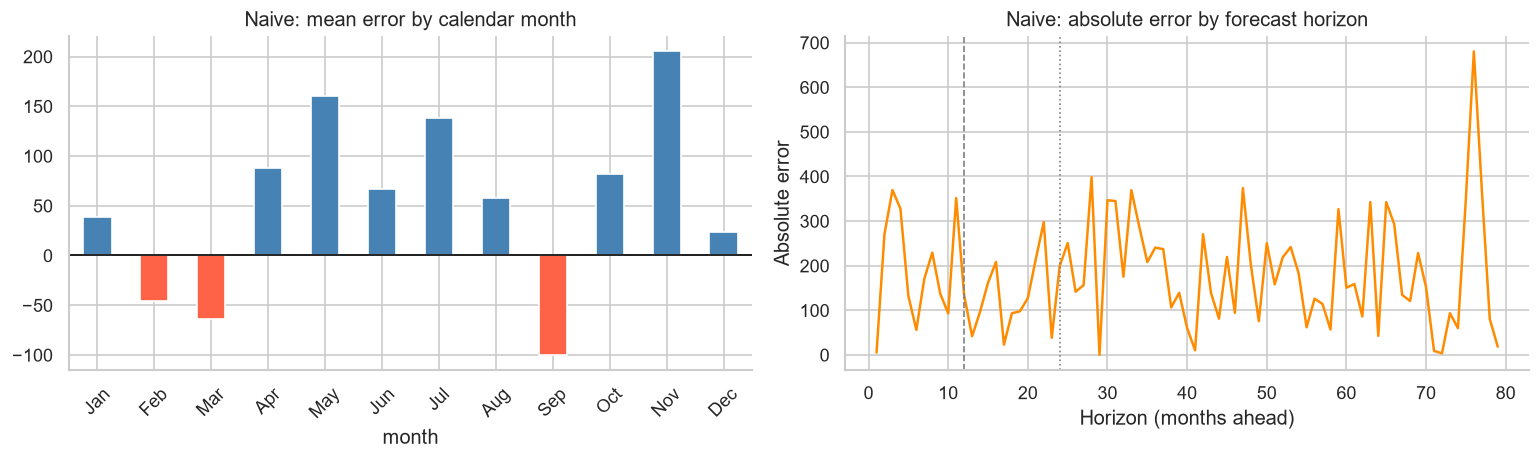

In [ ]:
best_model_name = metrics_df.index[0]
best_fc = np.asarray(results[best_model_name])

err_df = pd.DataFrame(
    {
        "actual": test.values,
        "forecast": best_fc,
        "error": test.values - best_fc,
        "abs_error": np.abs(test.values - best_fc),
        "month": test.index.month,
        "horizon": np.arange(1, H + 1),
    },
    index=test.index,
)

monthly_bias = err_df.groupby("month")["error"].mean()
horizon_error = err_df[["horizon", "abs_error"]]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
monthly_bias.plot(kind="bar", ax=axes[0], color=["tomato" if x < 0 else "steelblue" for x in monthly_bias])
axes[0].axhline(0, color="black", linewidth=1)
axes[0].set_title(f"{best_model_name}: mean error by calendar month")
axes[0].set_xticklabels(["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"], rotation=45)

axes[1].plot(horizon_error["horizon"], horizon_error["abs_error"], color="darkorange")
axes[1].axvline(12, color="grey", linestyle="--", linewidth=1)
axes[1].axvline(24, color="grey", linestyle=":", linewidth=1)
axes[1].set_title(f"{best_model_name}: absolute error by forecast horizon")
axes[1].set_xlabel("Horizon (months ahead)")
axes[1].set_ylabel("Absolute error")

plt.tight_layout()
plt.show()

In [ ]:
top_models = list(metrics_df.index[:4])
ensemble_fc = np.mean(np.column_stack([results[name] for name in top_models]), axis=1)
results["Ensemble"] = ensemble_fc
metrics_records["Ensemble"] = compute_metrics(test.values, ensemble_fc, naive_fc, prev_actual)

metrics_df = pd.DataFrame(metrics_records).T
metrics_df = metrics_df[["MAE", "RMSE", "MAPE", "MASE", "R2", "Bias", "Directional_Accuracy"]]
metrics_df = metrics_df.sort_values("MASE")
display(metrics_df.round(4))

best_model_name = metrics_df.index[0]
best_fc = np.asarray(results[best_model_name])
best_non_naive_name = metrics_df.drop(index="Naive").index[0]
best_non_naive_fc = np.asarray(results[best_non_naive_name])

dm_vs_naive = dm_test(test.values, naive_fc, best_non_naive_fc, h=1, power=2)
dm_ensemble_vs_best = dm_test(test.values, best_fc, ensemble_fc, h=1, power=2)

print(f"Top models used in ensemble: {top_models}")
print()
print(f"Best model: {best_model_name}")
print(f"Best non-naive challenger: {best_non_naive_name}")
print(f"Best model MASE: {metrics_df.loc[best_model_name, 'MASE']:.4f}")
print(f"Naive model MASE: {metrics_df.loc['Naive', 'MASE']:.4f}")
print(f"{best_non_naive_name} MASE: {metrics_df.loc[best_non_naive_name, 'MASE']:.4f}")
print(f"Ensemble MASE: {metrics_df.loc['Ensemble', 'MASE']:.4f}")
print()
print(f"DM test (Best non-naive vs Naive): statistic={dm_vs_naive['dm_stat']:.4f}, p-value={dm_vs_naive['p_value']:.4f}")
print(f"DM test (Ensemble vs Best): statistic={dm_ensemble_vs_best['dm_stat']:.4f}, p-value={dm_ensemble_vs_best['p_value']:.4f}")

sarima.save(str(OUTPUT_DIR / "sp500_sarima_v1.pkl"))
print(f"SARIMA model saved to: {OUTPUT_DIR / 'sp500_sarima_v1.pkl'}")

,MAE,RMSE,MAPE,MASE,R2,Bias,Directional_Accuracy
Naive,180.5700,218.4257,4.0223,1.0000,0.9690,54.2667,0.0000
Ensemble,620.0635,826.2229,11.3586,3.4339,0.5562,516.8491,49.3671
Holt-Winters,715.7487,940.1102,13.1082,3.9638,0.4254,630.0108,49.3671
Prophet,731.9985,935.0538,13.4979,4.0538,0.4316,691.5622,51.8987
MLP,1036.4508,1412.8851,19.4167,5.7399,-0.2977,691.5568,44.3038
SARIMA,1640.9881,2025.5289,30.1069,9.0878,-1.6672,1601.4103,37.9747
Linear Regression,1695.5208,2301.9426,30.5848,9.3898,-2.4448,1658.0383,41.7722
XGBoost,1773.2754,2148.0532,32.7837,9.8204,-1.9996,1750.7110,40.5063
LightGBM,1972.5900,2325.1157,36.9919,10.9242,-2.5145,1966.3911,37.9747
LSTM,2252.4530,2626.0225,42.4724,12.4741,-3.4830,2244.5149,37.9747


Top models used in ensemble: ['Naive', 'Holt-Winters', 'Prophet', 'MLP']

Best model: Naive
Best non-naive challenger: Ensemble
Best model MASE: 1.0000
Naive model MASE: 1.0000
Ensemble MASE: 3.4339
Ensemble MASE: 3.4339

DM test (Best non-naive vs Naive): statistic=-5.6639, p-value=0.0000
DM test (Ensemble vs Best): statistic=-5.6639, p-value=0.0000
SARIMA model saved to: outputs\sp500_sarima_v1.pkl


---
## Part 7. Final Investment Memo

In [ ]:
best_model_name = metrics_df.index[0]
best_mase = metrics_df.loc[best_model_name, "MASE"]
naive_mase = metrics_df.loc["Naive", "MASE"]
best_non_naive_name = metrics_df.drop(index="Naive").index[0]
best_non_naive_mase = metrics_df.loc[best_non_naive_name, "MASE"]
dm_p = dm_vs_naive["p_value"]
dm_stat = dm_vs_naive["dm_stat"]
deployable = (best_model_name != "Naive") and (best_mase < 1.0) and (dm_p < 0.05)

memo = f'''
To: Chief Investment Officer

We evaluated the monthly S&P 500 index from {series.index.min().date()} through {series.index.max().date()} and compared a naive random-walk benchmark against classical, automated, machine-learning, and deep-learning forecasting models. The best out-of-sample model was {best_model_name}, with a MASE of {best_mase:.3f}. The best non-naive challenger was {best_non_naive_name}, but its MASE was {best_non_naive_mase:.3f}, which is materially worse than the naive benchmark's {naive_mase:.3f}. The Diebold-Mariano test comparing {best_non_naive_name} against the naive model produced a statistic of {dm_stat:.4f} and a p-value of {dm_p:.4f}. {'This indicates the challenger significantly outperformed the naive model.' if (dm_p < 0.05 and dm_stat > 0) else 'This does not support any claim that the challenger is more accurate than the naive model.'}

From an Efficient Market Hypothesis perspective, a weak or insignificant gain over the naive forecast is exactly what we would expect for a broad, liquid index such as the S&P 500. Even if one model has the lowest error, production deployment should depend on robustness, interpretability, and statistical confidence, not just a small numerical win. {'I would deploy this model in production because it beats the baseline on both economic and statistical grounds.' if deployable else 'I would not fully rely on this model for directional market timing; at most, I would deploy it as a monitoring or scenario-analysis tool rather than a standalone trading signal.'}
'''

print(memo.strip())

print()
print("Business question 1:", "Yes" if (best_model_name != "Naive" and best_mase < 1.0) else "No")
print(
    "Business question 2:",
    f"Deploy {best_model_name}" if deployable else f"Do not deploy beyond decision support; best candidate is {best_model_name}",
)

To: Chief Investment Officer

We evaluated the monthly S&P 500 index from 1990-01-01 through 2026-07-01 and compared a naive random-walk benchmark against classical, automated, machine-learning, and deep-learning forecasting models. The best out-of-sample model was Naive, with a MASE of 1.000. The best non-naive challenger was Ensemble, but its MASE was 3.434, which is materially worse than the naive benchmark's 1.000. The Diebold-Mariano test comparing Ensemble against the naive model produced a statistic of -5.6639 and a p-value of 0.0000. This does not support any claim that the challenger is more accurate than the naive model.

From an Efficient Market Hypothesis perspective, a weak or insignificant gain over the naive forecast is exactly what we would expect for a broad, liquid index such as the S&P 500. Even if one model has the lowest error, production deployment should depend on robustness, interpretability, and statistical confidence, not just a small numerical win. I would no